### downloading dataset

In [ ]:
import kagglehub
# Downloads dataset and returns local path
path = kagglehub.dataset_download("abdulwadood11220/netflix-customer-churn-dataset")
print("Local path:", path)

import os
print(os.listdir(path))


100%|██████████| 186k/186k [00:00<00:00, 61.5MB/s]

Extracting files...
Local path: /root/.cache/kagglehub/datasets/abdulwadood11220/netflix-customer-churn-dataset/versions/1
['netflix_customer_churn.csv']


In [ ]:
import pandas as pd
df = pd.read_csv(os.path.join(path, 'netflix_customer_churn.csv'))

In [ ]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [ ]:
df.shape

(5000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

### `customer_id` Columns Removing

In [ ]:
df.drop(columns=['customer_id'], axis=1,inplace=True)

###  This is the data that i use in tableau and uploaded on the github



In [ ]:
from google.colab import files

# Export the DataFrame to a CSV file
file_name = 'exported_netflix_data.csv'
df.to_csv(file_name, index=False)

print(f'Successfully exported to {file_name}')

# Trigger a download in the browser
files.download(file_name)

Successfully exported to exported_netflix_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 1. Target Variable Distribution: Churn vs. Non-Churn

/tmp/ipykernel_7294/3126869206.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churned', palette='viridis')


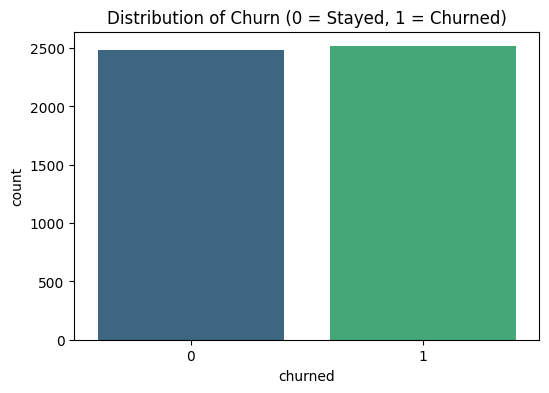

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churned', palette='viridis')
plt.title('Distribution of Churn (0 = Stayed, 1 = Churned)')
plt.show()

### 2. Churn Analysis by Subscription Type and Gender

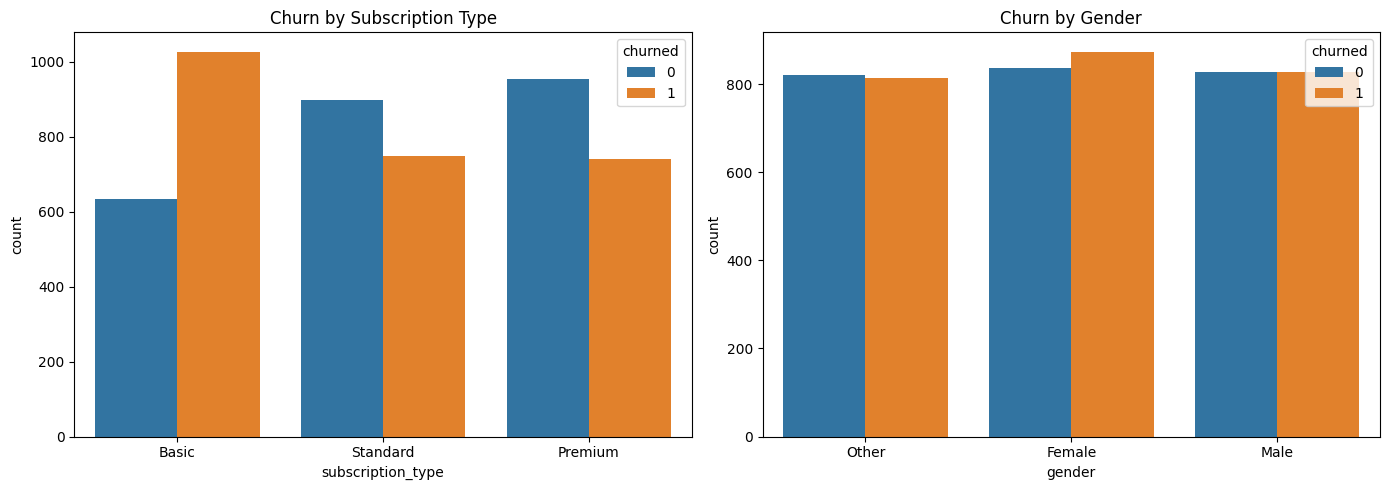

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='subscription_type', hue='churned', ax=axes[0])
axes[0].set_title('Churn by Subscription Type')

sns.countplot(data=df, x='gender', hue='churned', ax=axes[1])
axes[1].set_title('Churn by Gender')

plt.tight_layout()
plt.show()

### 3. Behavioral Analysis: Watch Hours and Monthly Fees

/tmp/ipykernel_7294/426939816.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churned', y='watch_hours', palette='magma')


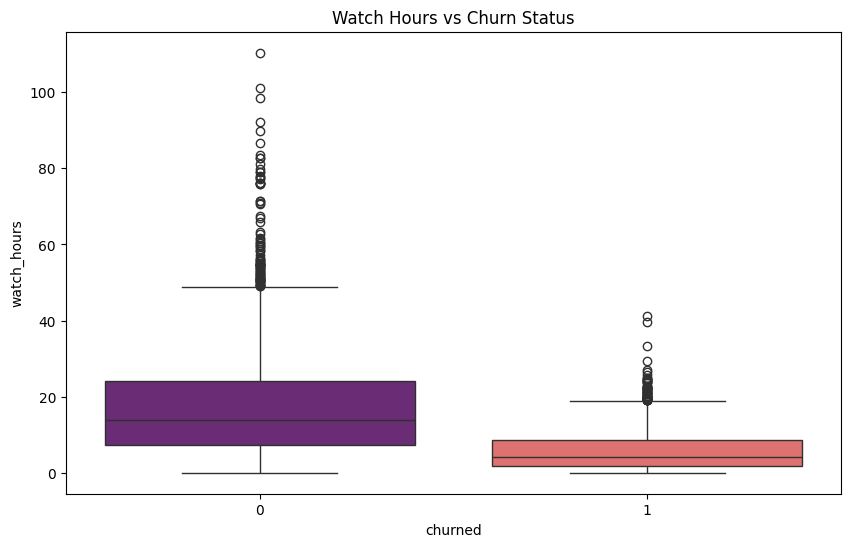

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='churned', y='watch_hours', palette='magma')
plt.title('Watch Hours vs Churn Status')
plt.show()

### 4. Regional Distribution of Users

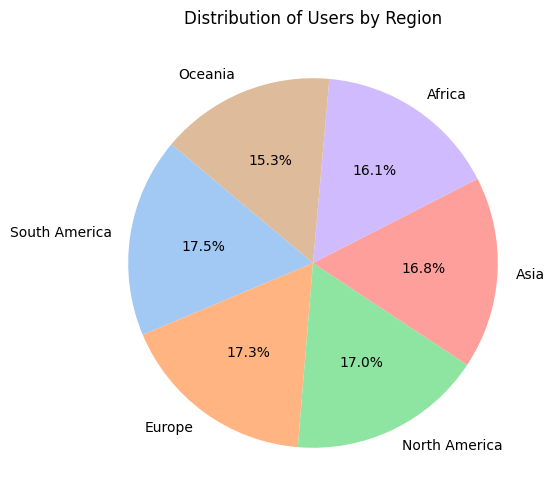

In [ ]:
plt.figure(figsize=(12, 6))
region_counts = df['region'].value_counts()
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Users by Region')
plt.show()

### 5. Statistical Correlation Matrix

--- Correlation with Churn (Highest to Lowest) ---
churned                   1.000000
last_login_days           0.471590
age                      -0.003515
monthly_fee              -0.152117
number_of_profiles       -0.158614
avg_watch_time_per_day   -0.272958
watch_hours              -0.479916
Name: churned, dtype: float64


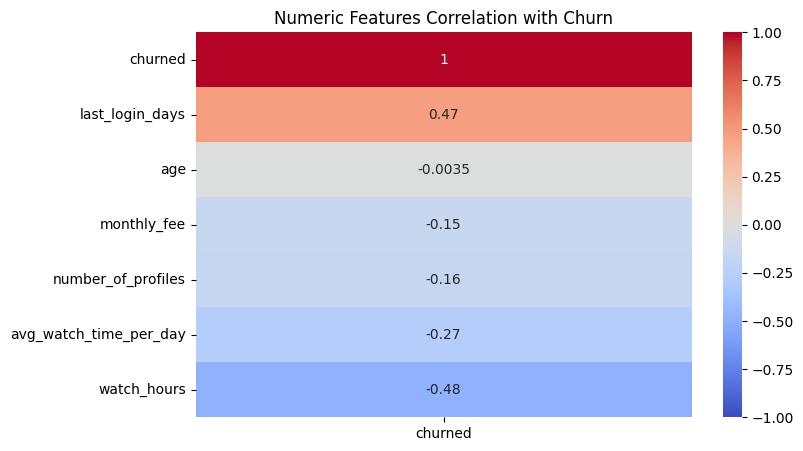

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlations specifically with the churn column
correlations = df.corr(numeric_only=True)['churned'].sort_values(ascending=False)

print("--- Correlation with Churn (Highest to Lowest) ---")
print(correlations)

# Plot a mini heatmap of numeric correlations
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True)[['churned']].sort_values(by='churned', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Numeric Features Correlation with Churn')
plt.show()

### 6. Multi-variable Churn Rate Analysis

/tmp/ipykernel_7294/1034310112.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  churn_matrix = df.pivot_table(index='number_of_profiles',


--- Churn Rate Matrix (1.0 = 100% Churn, 0.0 = 0% Churn) ---
watch_hour_bucket    0-5 hrs  5-10 hrs  10-15 hrs  15-25 hrs   25+ hrs
number_of_profiles                                                    
1                   0.920245  0.555556   0.564626   0.325153  0.039216
2                   0.917143  0.524000   0.475524   0.319527  0.011364
3                   0.931319  0.514019   0.527778   0.337931  0.007874
4                   0.724138  0.309322   0.315436   0.149351  0.007092
5                   0.717762  0.305556   0.293706   0.121429  0.000000


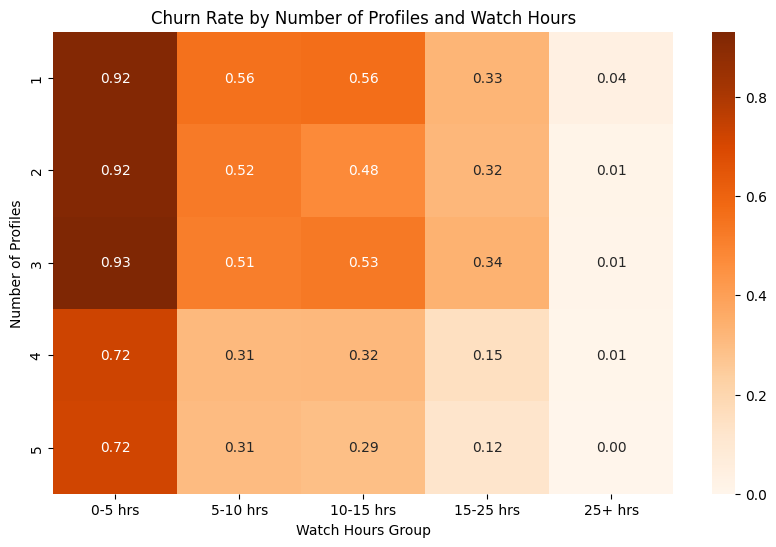

In [ ]:
# Creating bins for watch hours to group users dynamically
df['watch_hour_bucket'] = pd.cut(df['watch_hours'], bins=[0, 5, 10, 15, 25, 100],
                                 labels=['0-5 hrs', '5-10 hrs', '10-15 hrs', '15-25 hrs', '25+ hrs'])

# Fixed: Changed index from 'num_profiles' to 'number_of_profiles'
churn_matrix = df.pivot_table(index='number_of_profiles',
                              columns='watch_hour_bucket',
                              values='churned',
                              aggfunc='mean')

print("--- Churn Rate Matrix (1.0 = 100% Churn, 0.0 = 0% Churn) ---")
print(churn_matrix)

# Visualize the risk zones
plt.figure(figsize=(10, 6))
sns.heatmap(churn_matrix, annot=True, fmt=".2f", cmap='Oranges')
plt.title('Churn Rate by Number of Profiles and Watch Hours')
plt.ylabel('Number of Profiles')
plt.xlabel('Watch Hours Group')
plt.show()

### 7. Feature Importance Ranking

--- Feature Importance Ranking (What drives churn predictions most) ---
avg_watch_time_per_day    0.390893
watch_hours               0.211066
last_login_days           0.180246
number_of_profiles        0.065168
payment_method            0.037911
monthly_fee               0.027165
age                       0.022546
subscription_type         0.021387
favorite_genre            0.013187
region                    0.012134
device                    0.010352
gender                    0.007945
dtype: float64


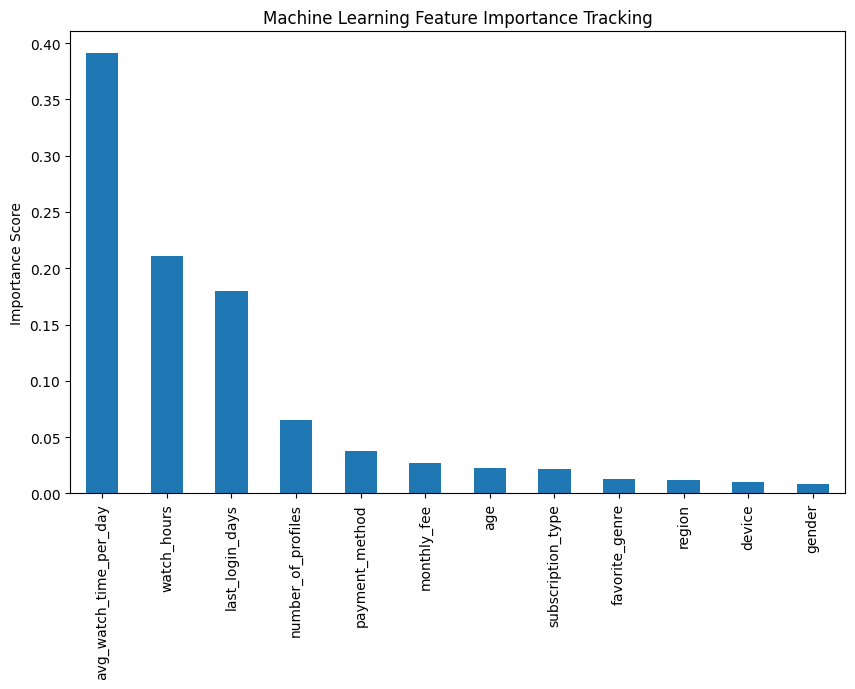

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Copy dataframe to protect original data
ml_df = df.copy()

# Drop helper columns if created in previous cells
if 'watch_hour_bucket' in ml_df.columns:
    ml_df = ml_df.drop(columns=['watch_hour_bucket'])

# Convert all text categories to numbers for the algorithm
le = LabelEncoder()
for col in ml_df.select_dtypes(include=['object']).columns:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

# Separate features (X) and target variable (y)
X = ml_df.drop(columns=['churned'])
y = ml_df['churned']

# Train a quick Random Forest model to measure feature weights
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Match features to their importance scores
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("--- Feature Importance Ranking (What drives churn predictions most) ---")
print(importances)

# Plot feature importance
plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Machine Learning Feature Importance Tracking')
plt.ylabel('Importance Score')
plt.show()

### 8. Joint Behavioral Plot

<Figure size 1000x800 with 0 Axes>

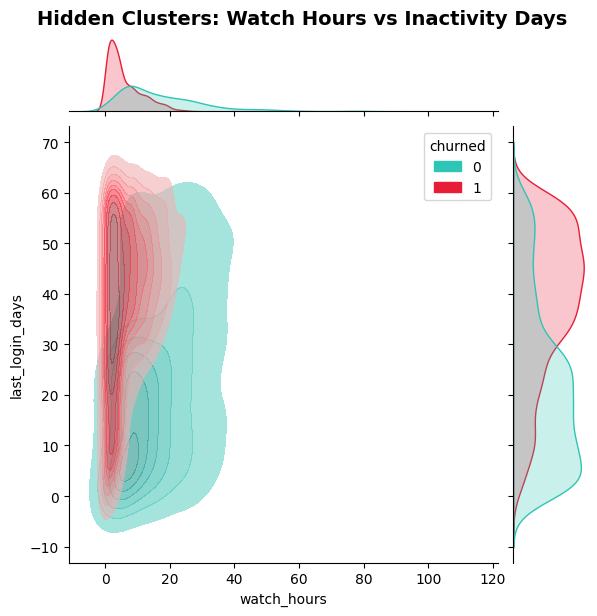

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Jointplot shows both the scatter points and the density distribution at the same time
g = sns.jointplot(
    data=df,
    x="watch_hours",
    y="last_login_days",
    hue="churned",
    palette={0: "#2ec4b6", 1: "#e71d36"}, # Teal for retained, Red for churned
    alpha=0.6,
    kind="kde", # Kernel Density Estimate to highlight hidden clusters
    fill=True
)

g.fig.suptitle("Hidden Clusters: Watch Hours vs Inactivity Days", y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 9. Plan vs Device Churn Risk Matrix Graph

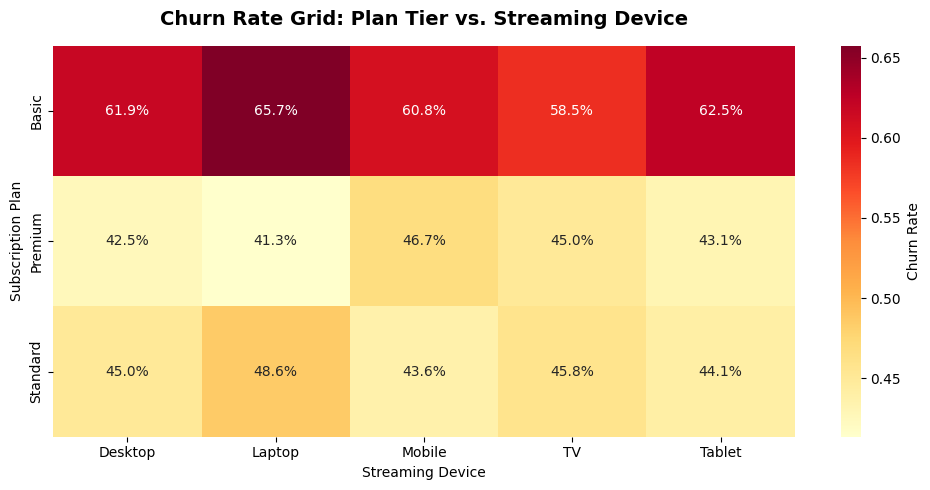

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the average churn rate across dimensions
pivot_df = df.groupby(['subscription_type', 'device'])['churned'].mean().unstack()

plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".1%", # Displays values as clean percentages (e.g., 45.2%)
    cmap="YlOrRd", # Yellow to Orange to Red gradient for risk mapping
    cbar_kws={'label': 'Churn Rate'}
)

plt.title("Churn Rate Grid: Plan Tier vs. Streaming Device", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Streaming Device")
plt.ylabel("Subscription Plan")
plt.tight_layout()
plt.show()

### 10. Price Distribution by Genre and Churn Status

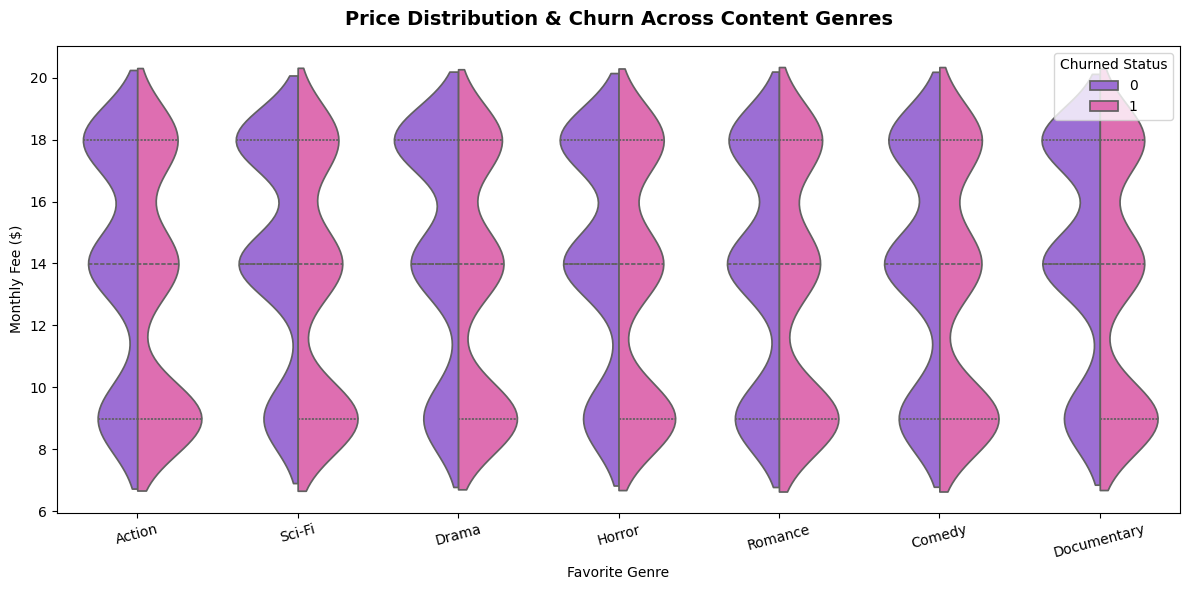

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Split=True creates a single violin split in half (Left: Retained, Right: Churned)
sns.violinplot(
    data=df,
    x="favorite_genre",
    y="monthly_fee",
    hue="churned",
    split=True,
    palette={0: "#9b5de5", 1: "#f15bb5"}, # Custom distinct palette
    inner="quart" # Draws horizontal lines at the 25th, 50th, and 75th percentiles
)

plt.title("Price Distribution & Churn Across Content Genres", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Favorite Genre")
plt.ylabel("Monthly Fee ($)")
plt.xticks(rotation=15)
plt.legend(title="Churned Status", loc="upper right")
plt.tight_layout()
plt.show()

### 11. Churn Probability Curve by Engagement

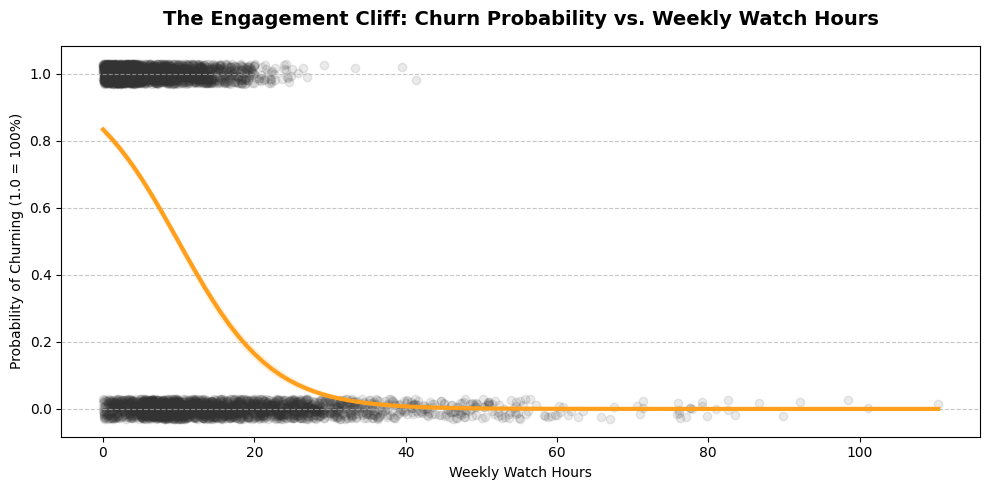

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# logistic=True fits a statistical regression curve showing probability between 0 and 1
sns.regplot(
    data=df,
    x="watch_hours",
    y="churned",
    logistic=True,
    y_jitter=0.03, # Adds minor spacing to data points so they don't overlap flatly
    scatter_kws={'alpha': 0.1, 'color': '#333333'},
    line_kws={'color': '#ff9f1c', 'linewidth': 3} # Bold orange trendline
)

plt.title("The Engagement Cliff: Churn Probability vs. Weekly Watch Hours", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Weekly Watch Hours")
plt.ylabel("Probability of Churning (1.0 = 100%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 12. correlation heatmap

<Axes: >

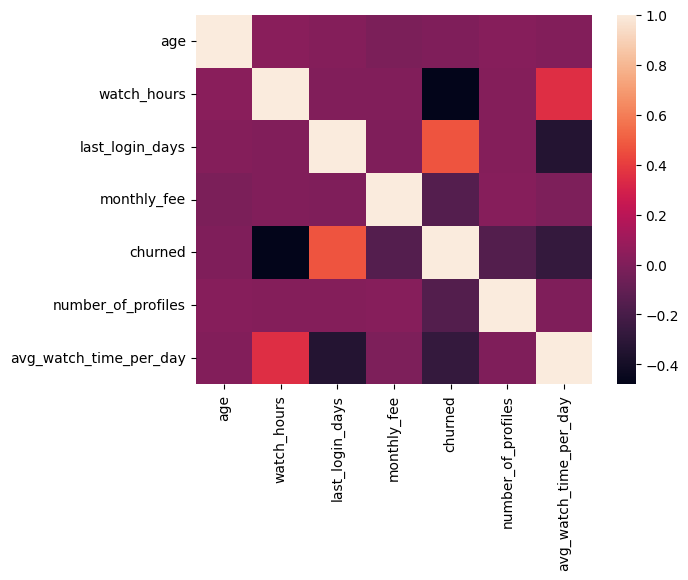

In [ ]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True))

### 1. Data Preparation and Pipeline Setup
We will define which columns need scaling and which need encoding, then build a `ColumnTransformer`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define feature groups
numeric_features = ['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day']
categorical_features = ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Qu
         antileTransformer(output_distribution='normal', random_state=42), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Split the data
X = df.drop(columns=['churned'])
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Preprocessing pipeline defined. Training set size: {X_train.shape[0]}")

Preprocessing pipeline defined. Training set size: 4000


### 2. Training Multiple Classifiers
We will evaluate Logistic Regression, Random Forest, and an XGBoost-style Gradient Booster.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    # Create a pipeline that first preprocesses then trains the model
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


--- Logistic Regression ---
Accuracy: 0.8850
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       497
           1       0.87      0.90      0.89       503

    accuracy                           0.89      1000
   macro avg       0.89      0.88      0.88      1000
weighted avg       0.89      0.89      0.88      1000


--- Random Forest ---
Accuracy: 0.9760
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       497
           1       0.97      0.98      0.98       503

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


--- Gradient Boosting ---
Accuracy: 0.9880
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       497
           1       0.99      0.99      0.99       503

    accuracy                           0.99      100

### 3. Training an Artificial Neural Network (ANN)
We will use TensorFlow/Keras to build a deep learning model. We must first transform our data using the `preprocessor` we defined earlier.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Transform the data using our pipeline preprocessor
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Build the ANN architecture
ann_model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_transformed.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = ann_model.fit(
    X_train_transformed, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Evaluate and store results
loss, ann_accuracy = ann_model.evaluate(X_test_transformed, y_test, verbose=0)
results["Neural Network"] = ann_accuracy

print(f"ANN Accuracy: {ann_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN Accuracy: 0.9050


### 4. Final Model Comparison
Let's update our comparison chart to include the Neural Network.

/tmp/ipykernel_7294/543556006.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='Accuracy', palette='viridis')


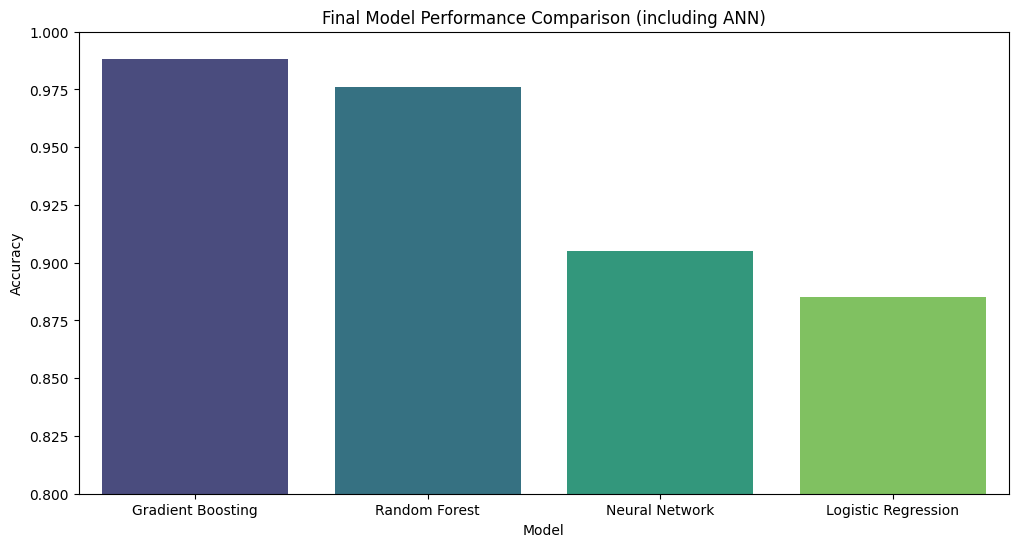

In [ ]:
plt.figure(figsize=(12, 6))
comparison_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
sns.barplot(data=comparison_df, x='Model', y='Accuracy', palette='viridis')
plt.title('Final Model Performance Comparison (including ANN)')
plt.ylim(0.8, 1.0) # Zoomed in to see differences
plt.show()